In [1]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


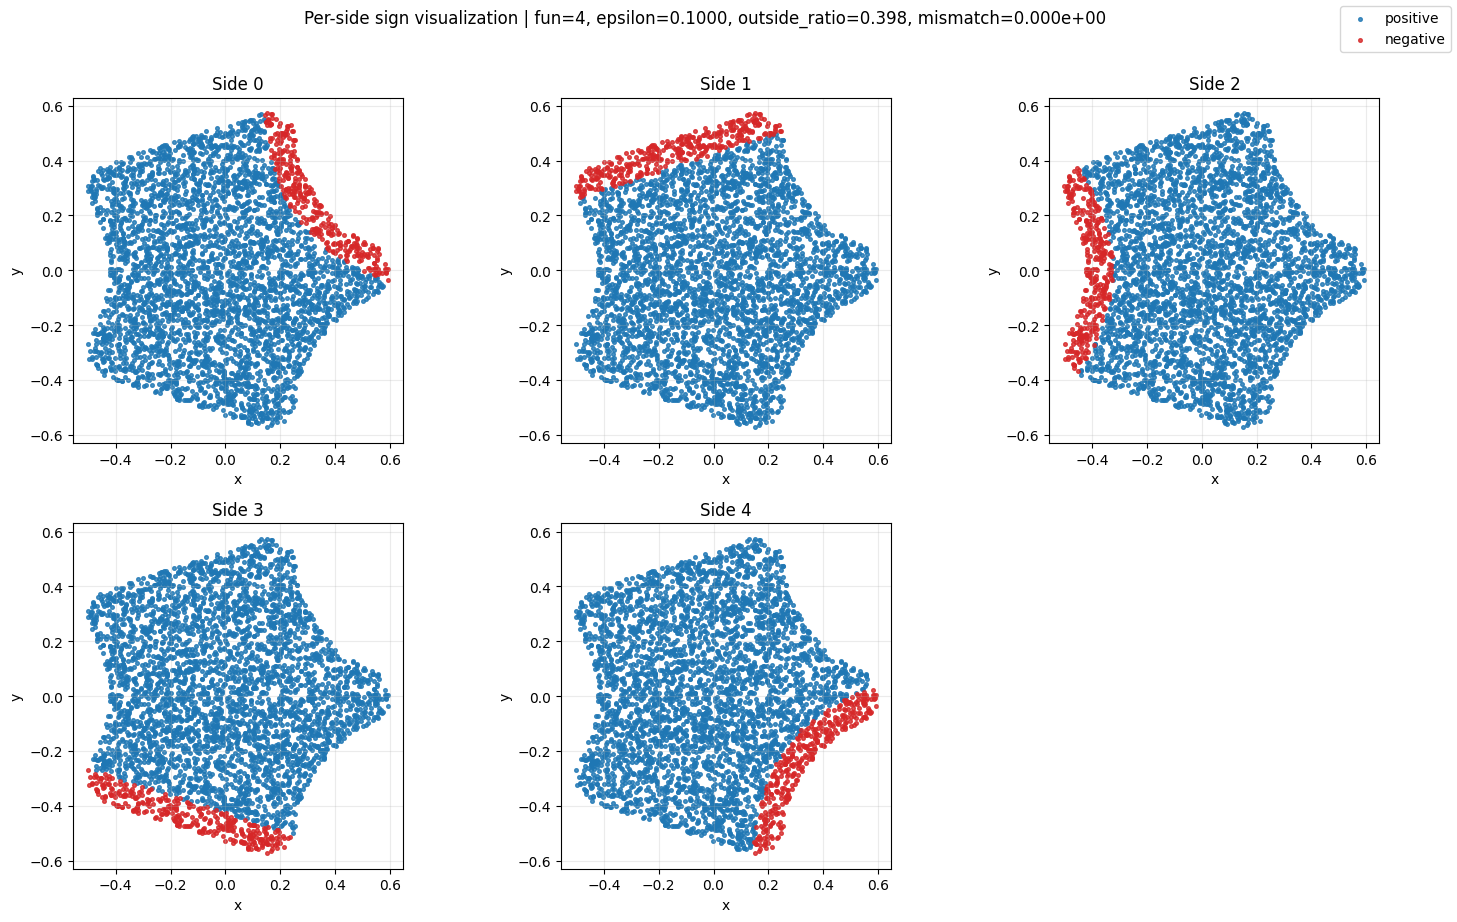

In [3]:
_=NI.visualize_epsilon_side_signs(fun_num=4,epsilon=0.1)

In [4]:
architecture = [2, 256,256,256,256,5]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 199429


In [13]:
NUM_EPOCHS = 5000
BATCH_SIZE = 1024
FUN_NUM = 4
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      epsilon=1e-1,
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.0011779913286389819, Acc: 0.0011779913286389819
Epoch [499], Loss: 0.0008714271996532322, Acc: 0.0008714271996532322
Epoch [999], Loss: 0.0007737779565809696, Acc: 0.0007737779565809696
Epoch [1499], Loss: 0.0007105553958845826, Acc: 0.0007105553958845826
Epoch [1999], Loss: 0.0006082412519224673, Acc: 0.0006082412519224673
Epoch [2499], Loss: 0.0006239558562092988, Acc: 0.0006239558562092988
Epoch [2999], Loss: 0.0006106341853165908, Acc: 0.0006106341853165908
Epoch [3499], Loss: 0.0005307217307241941, Acc: 0.0005307217307241941
Epoch [3999], Loss: 0.0004771456138839127, Acc: 0.0004771456138839127
Epoch [4499], Loss: 0.0005349899670248475, Acc: 0.0005349899670248475
Epoch [4999], Loss: 0.0004981544971546651, Acc: 0.0004981544971546651


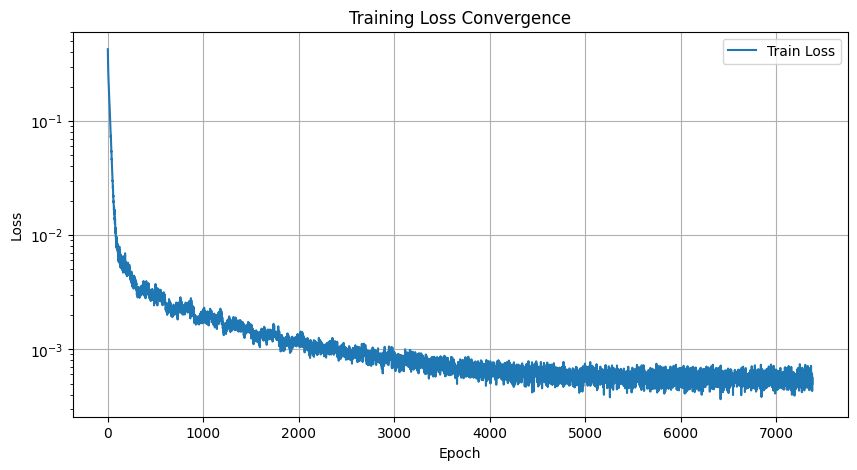

In [14]:
#plot convergence
plt.figure(figsize=(10,5))
plt.plot(model.loss_history, label='Train Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.legend()
plt.grid()
plt.show()

In [15]:
NI.evaluate_model_random_points(model, N=10000, function_case=FUN_NUM, device=torch.device('cpu'))

Model evaluation on N=10000 random points (function_case=4):
  Value errors: mean_abs=5.464417e-05, max_abs=1.308933e-03, L2=7.600186e-05
  Grad-norm errors (|grad|-1): mean_abs=2.526155e-03, max_abs=7.572816e-02, L2=3.459593e-03
  Hessian-diagonal errors (target 0): mean_abs=4.598267e-01, max_abs=7.656651e+00, L2=6.547979e-01


{'N': 10000,
 'function_case': 4,
 'global': {'value_mean_abs_error': 5.464416509965728e-05,
  'value_max_abs_error': 0.001308932711327591,
  'value_l2_error': 7.60018603320362e-05,
  'grad_norm_mean_abs_error': 0.0025261552643306056,
  'grad_norm_max_abs_error': 0.07572816157389717,
  'grad_norm_l2_error': 0.00345959272050047,
  'hessian_diag_mean_abs_error': 0.45982666911105463,
  'hessian_diag_max_abs_error': 7.656650757015306,
  'hessian_diag_l2_error': 0.6547978728247569}}

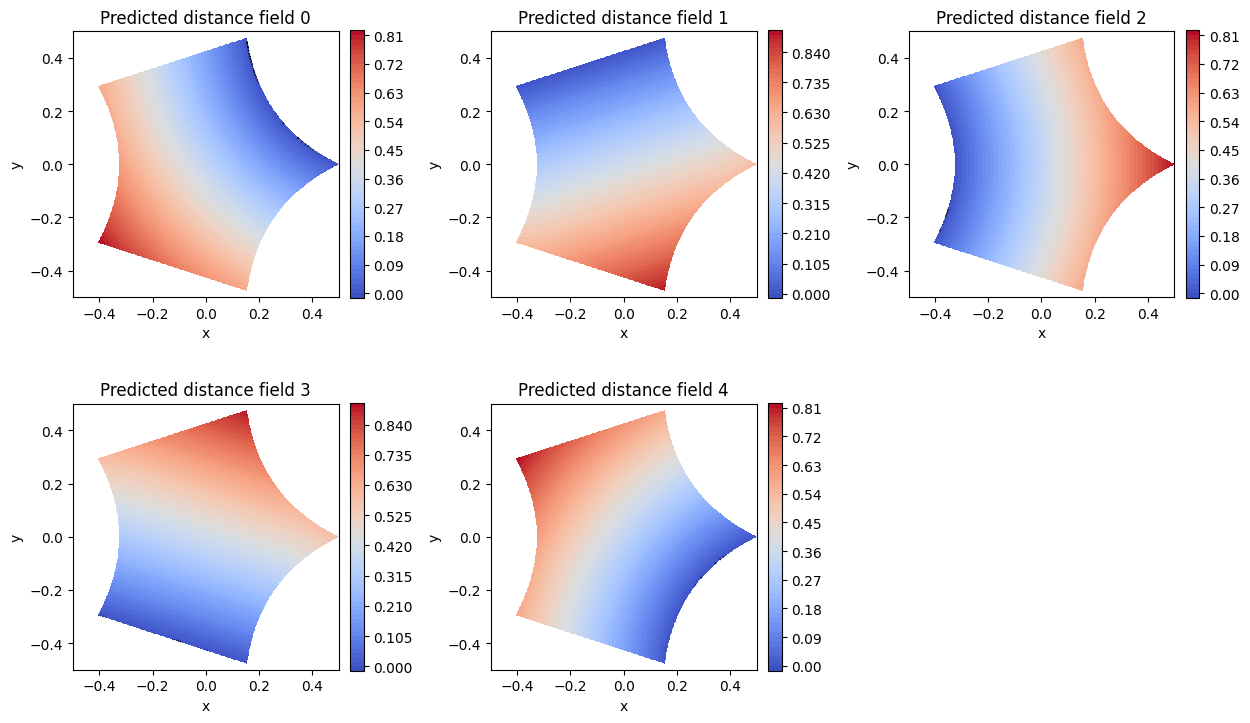

In [9]:
_=NI.plot_nn_distance_fields(model, extent=[-0.5,0.5,-0.5,0.5], mask_outside_domain=True, fun_num=FUN_NUM, device=torch.device('cpu'))

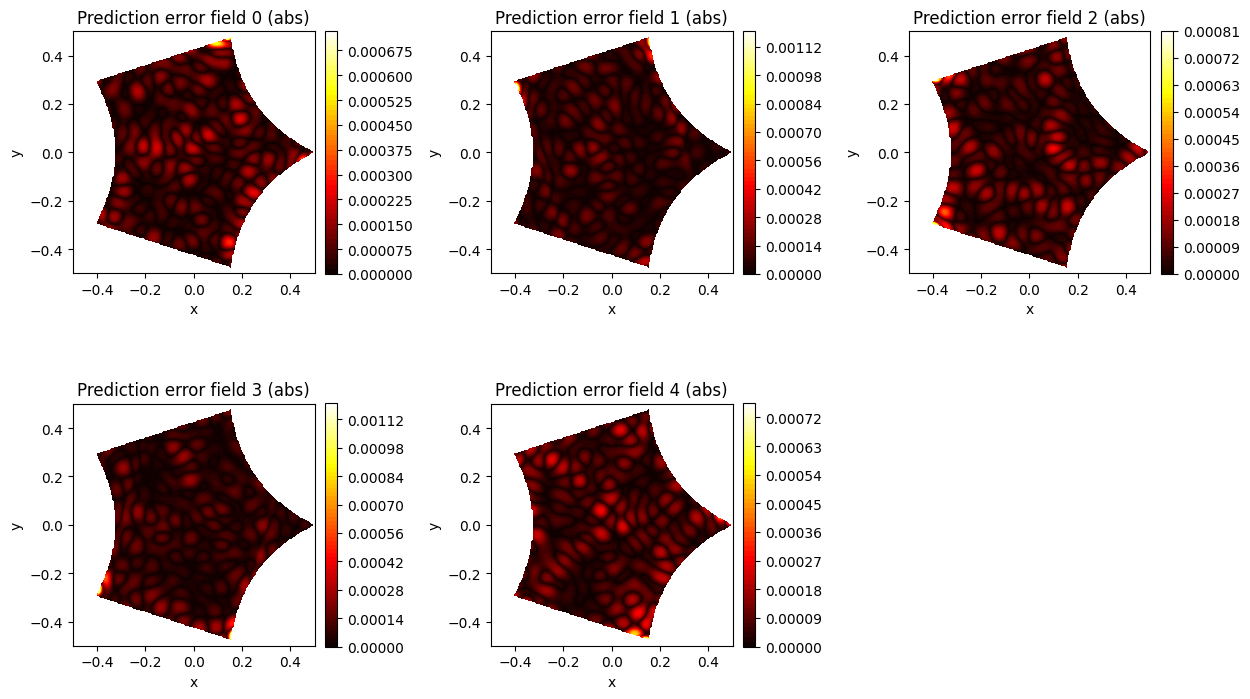

In [16]:
_=NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=FUN_NUM, device=torch.device('cpu'))

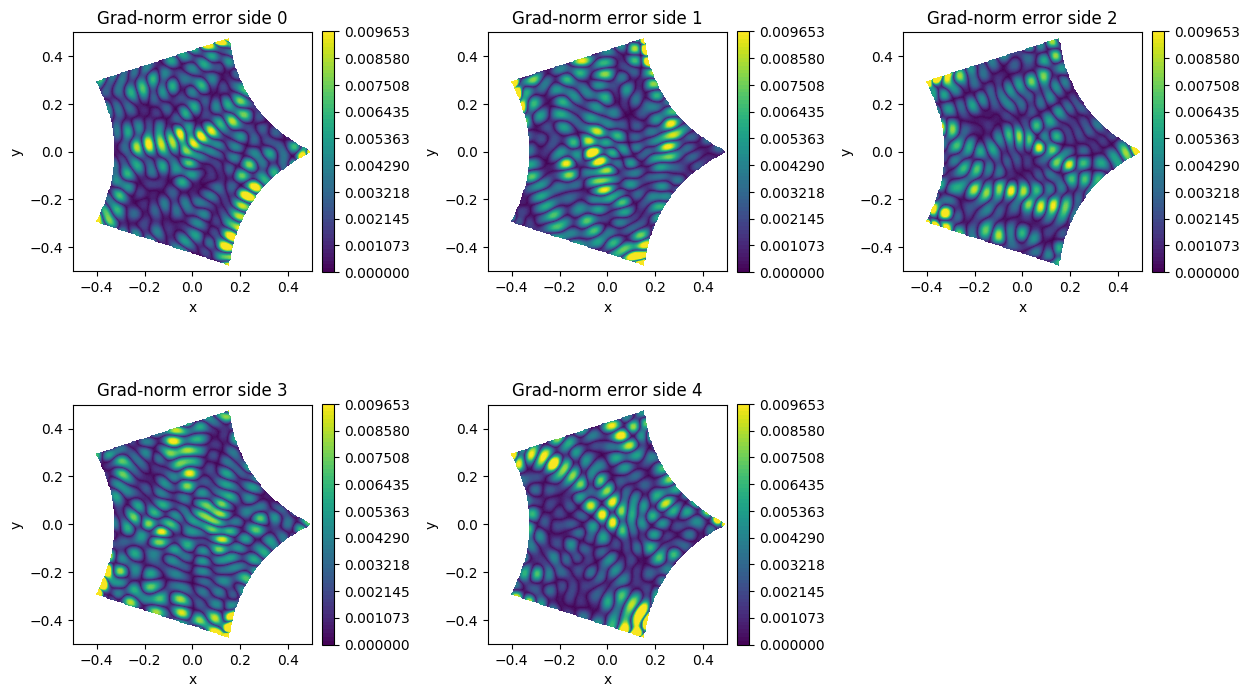

In [17]:
_=NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5],fun_num=FUN_NUM, device=torch.device('cpu'), cmap='viridis')

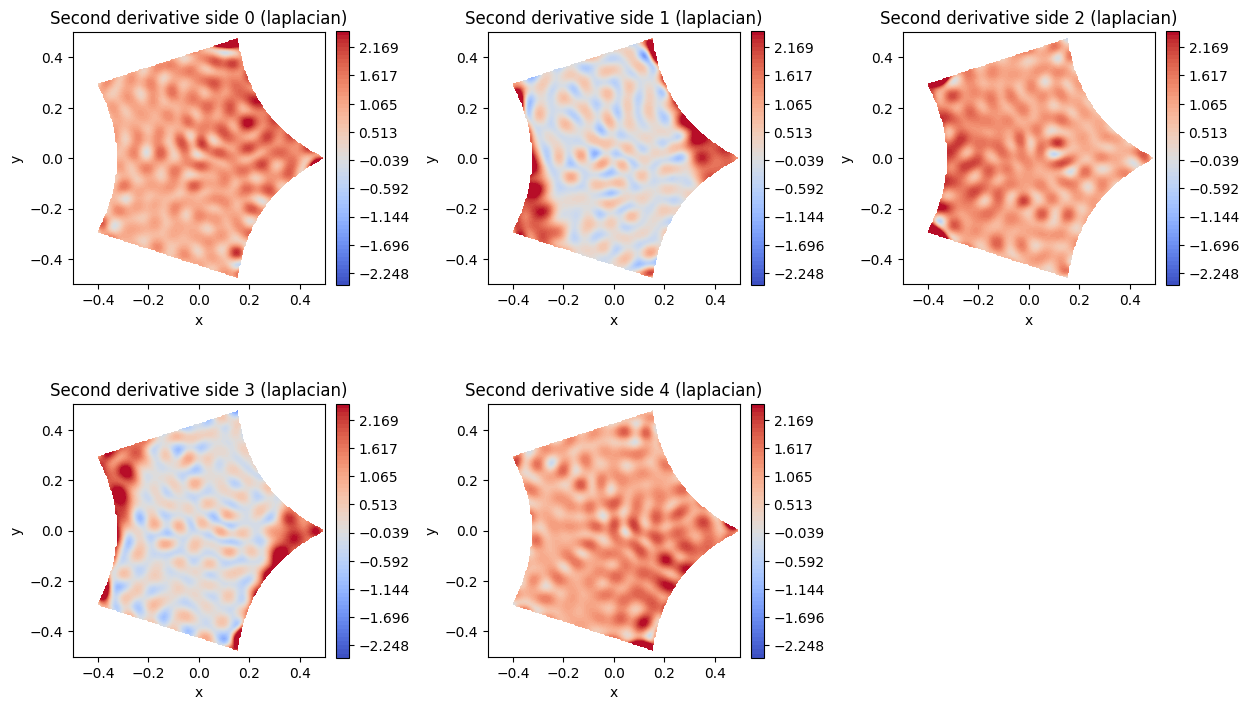

In [18]:
_=NI.plot_local_per_side_second_derivative(model, extent=[-0.5,0.5,-0.5,0.5], mask_outside_domain=True, device=torch.device('cpu'),fun_num=FUN_NUM)

# No externalsampling

In [21]:
architecture = [2, 256,256,256,256,5]
model2 = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model2.parameters())}')
model2.optimizer = torch.optim.Adam(model2.parameters(), lr=5e-5)
model2.lr_scheduler = torch.optim.lr_scheduler.StepLR(model2.optimizer, step_size=300, gamma=0.8)


Number of parameters: 199429


In [22]:
NUM_EPOCHS = 10000
BATCH_SIZE = 1024
FUN_NUM = 4
NI.train_model_simple(model2, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      epsilon=0,
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.367075831420821, Acc: 0.367075831420821
Epoch [999], Loss: 0.001355010909099784, Acc: 0.001355010909099784
Epoch [1999], Loss: 0.0005624213678698774, Acc: 0.0005624213678698774
Epoch [2999], Loss: 0.00031501358246743957, Acc: 0.00031501358246743957
Epoch [3999], Loss: 0.00014415601790259382, Acc: 0.00014415601790259382
Epoch [4999], Loss: 8.136479434486742e-05, Acc: 8.136479434486742e-05
Epoch [5999], Loss: 5.7236042503578245e-05, Acc: 5.7236042503578245e-05
Epoch [6999], Loss: 5.3142277371891765e-05, Acc: 5.3142277371891765e-05
Epoch [7999], Loss: 4.649017470944573e-05, Acc: 4.649017470944573e-05
Epoch [8999], Loss: 5.165580894419099e-05, Acc: 5.165580894419099e-05
Epoch [9999], Loss: 4.3994853451133406e-05, Acc: 4.3994853451133406e-05


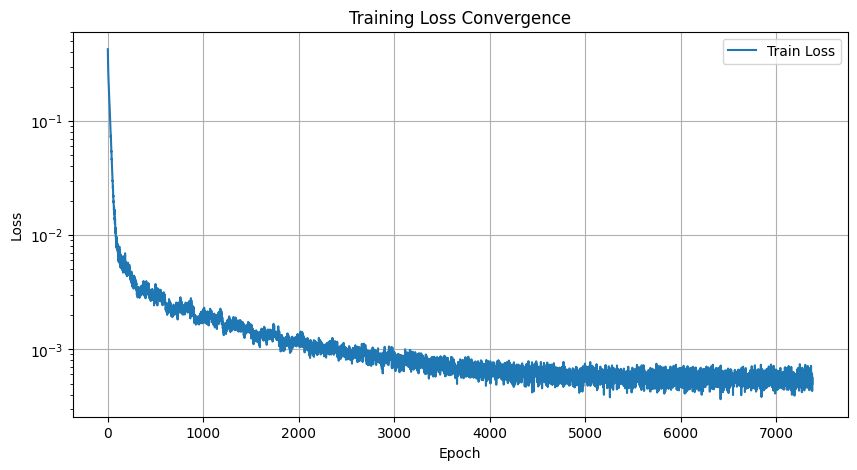

In [23]:
#plot convergence
plt.figure(figsize=(10,5))
plt.plot(model.loss_history, label='Train Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.legend()
plt.grid()
plt.show()

In [26]:
NI.evaluate_model_random_points(model2, N=10000, function_case=FUN_NUM, device=torch.device('cpu'))

Model evaluation on N=10000 random points (function_case=4):
  Value errors: mean_abs=4.657350e-05, max_abs=1.157238e-02, L2=1.667353e-04
  Grad-norm errors (|grad|-1): mean_abs=3.684097e-03, max_abs=8.451880e-01, L2=1.558357e-02
  Hessian-diagonal errors (target 0): mean_abs=5.589477e-01, max_abs=3.775546e+01, L2=1.126671e+00


{'N': 10000,
 'function_case': 4,
 'global': {'value_mean_abs_error': 4.6573495626342785e-05,
  'value_max_abs_error': 0.011572376392247508,
  'value_l2_error': 0.00016673534777873858,
  'grad_norm_mean_abs_error': 0.0036840972512048073,
  'grad_norm_max_abs_error': 0.8451880447213782,
  'grad_norm_l2_error': 0.015583568146135943,
  'hessian_diag_mean_abs_error': 0.5589477038485016,
  'hessian_diag_max_abs_error': 37.75546218071712,
  'hessian_diag_l2_error': 1.1266708306549265}}

In [28]:
NI.evaluate_model_random_points(model, N=10000, function_case=FUN_NUM, device=torch.device('cpu'))

Model evaluation on N=10000 random points (function_case=4):
  Value errors: mean_abs=5.489870e-05, max_abs=1.299822e-03, L2=7.694456e-05
  Grad-norm errors (|grad|-1): mean_abs=2.520815e-03, max_abs=6.191502e-02, L2=3.451444e-03
  Hessian-diagonal errors (target 0): mean_abs=4.605247e-01, max_abs=8.051911e+00, L2=6.550579e-01


{'N': 10000,
 'function_case': 4,
 'global': {'value_mean_abs_error': 5.4898696820592366e-05,
  'value_max_abs_error': 0.0012998215567280001,
  'value_l2_error': 7.694455565297811e-05,
  'grad_norm_mean_abs_error': 0.0025208154002064917,
  'grad_norm_max_abs_error': 0.06191501857551218,
  'grad_norm_l2_error': 0.0034514439196060005,
  'hessian_diag_mean_abs_error': 0.4605246638350512,
  'hessian_diag_max_abs_error': 8.051910893505623,
  'hessian_diag_l2_error': 0.6550578951309864}}

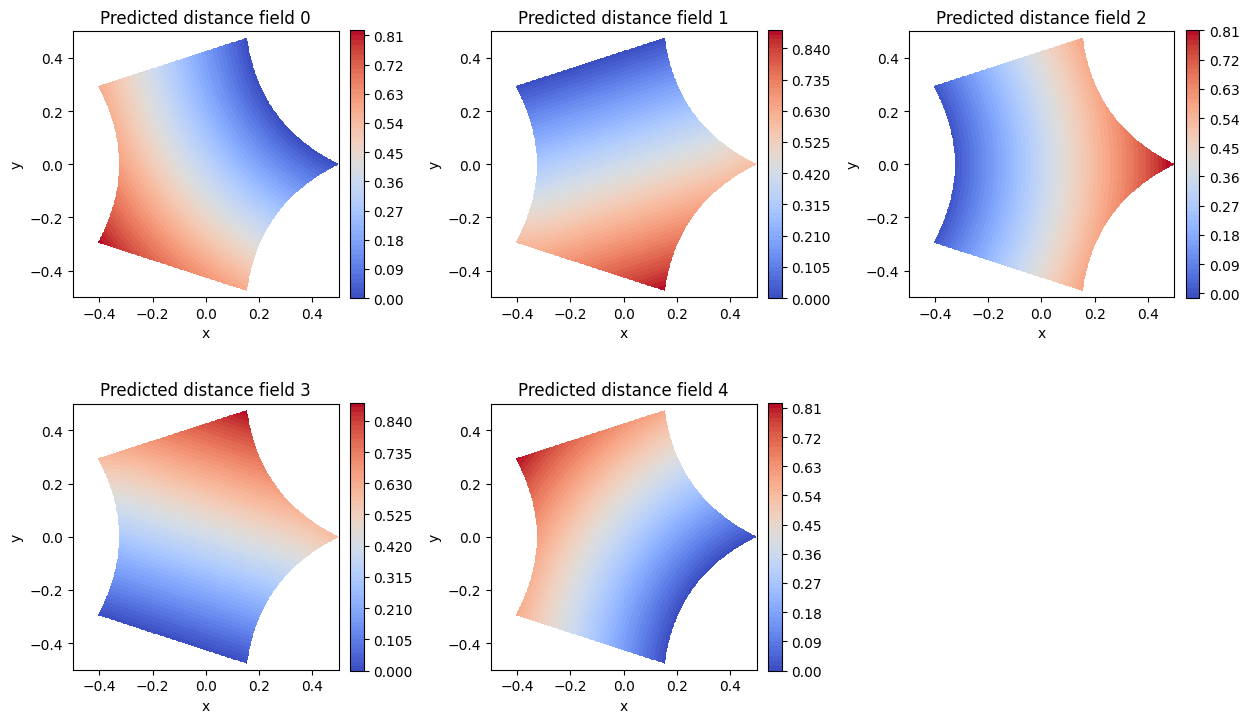

In [25]:
_=NI.plot_nn_distance_fields(model2, extent=[-0.5,0.5,-0.5,0.5], mask_outside_domain=True, fun_num=FUN_NUM, device=torch.device('cpu'))

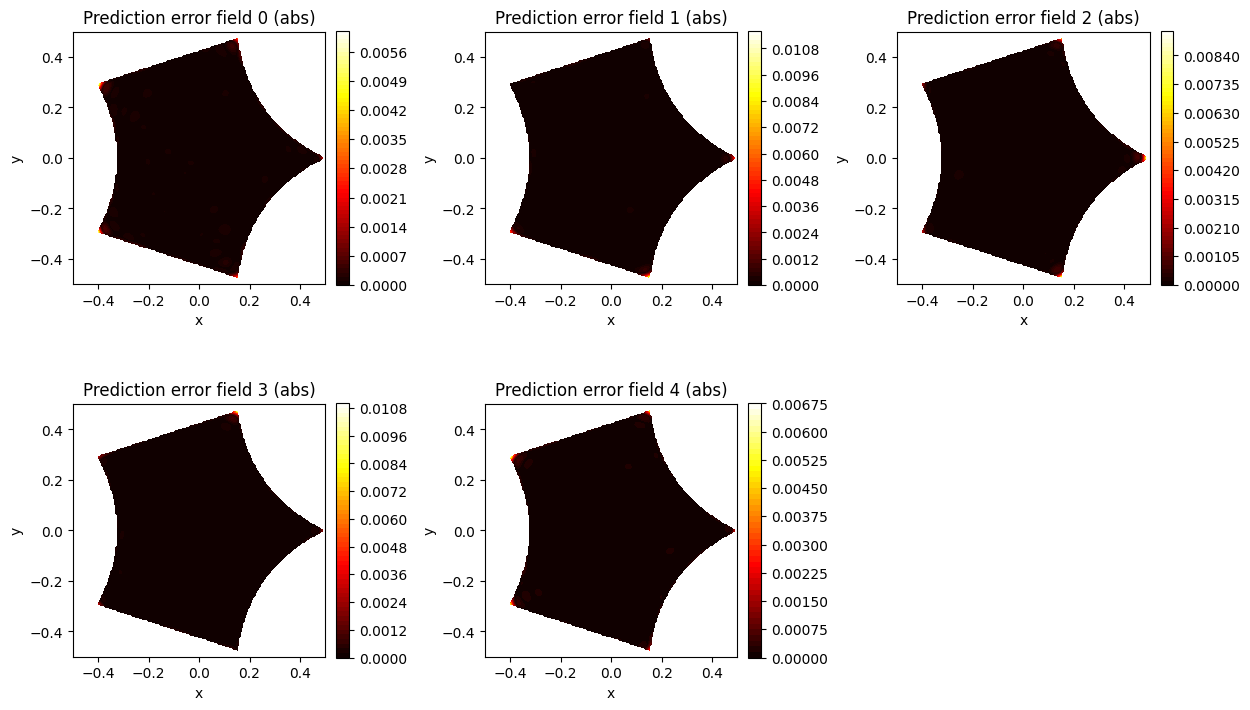

In [30]:
_=NI.plot_nn_prediction_error(model2, extent=[-0.5,0.5,-0.5,0.5], fun_num=FUN_NUM, device=torch.device('cpu'))

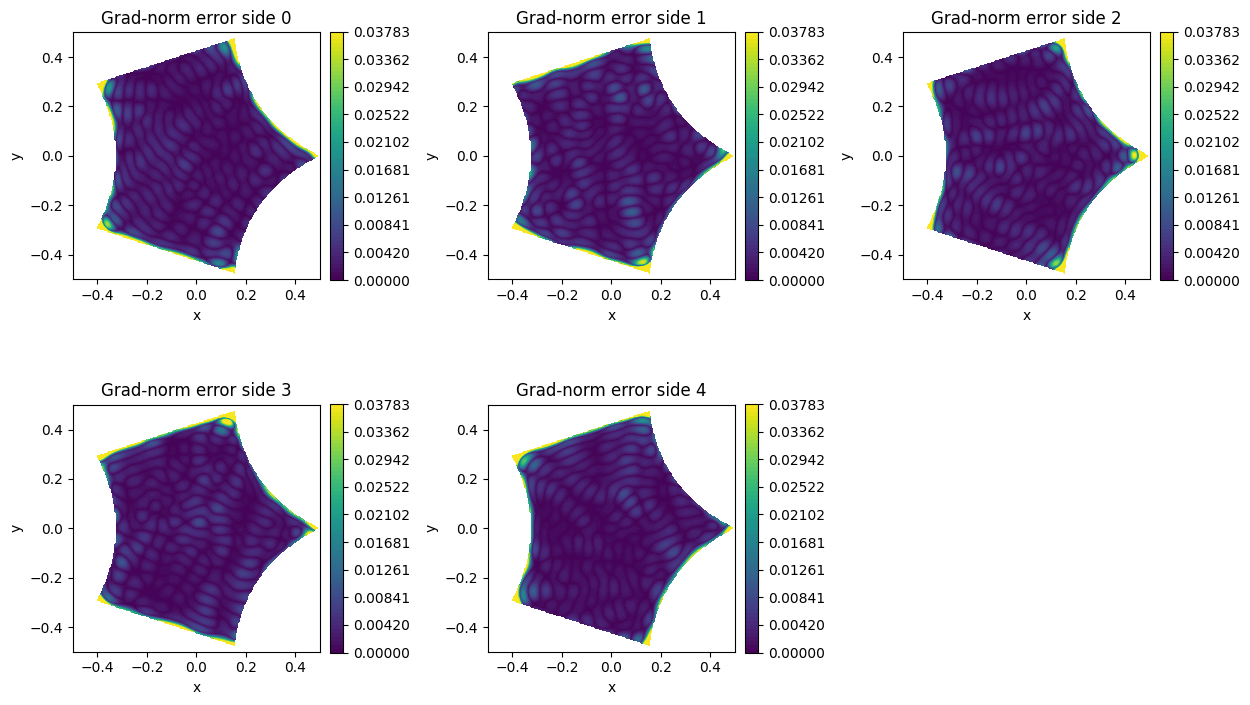

In [34]:
_=NI.plot_local_per_side_gradient_error(model2, extent=[-0.5,0.5,-0.5,0.5],fun_num=FUN_NUM, device=torch.device('cpu'), cmap='viridis')

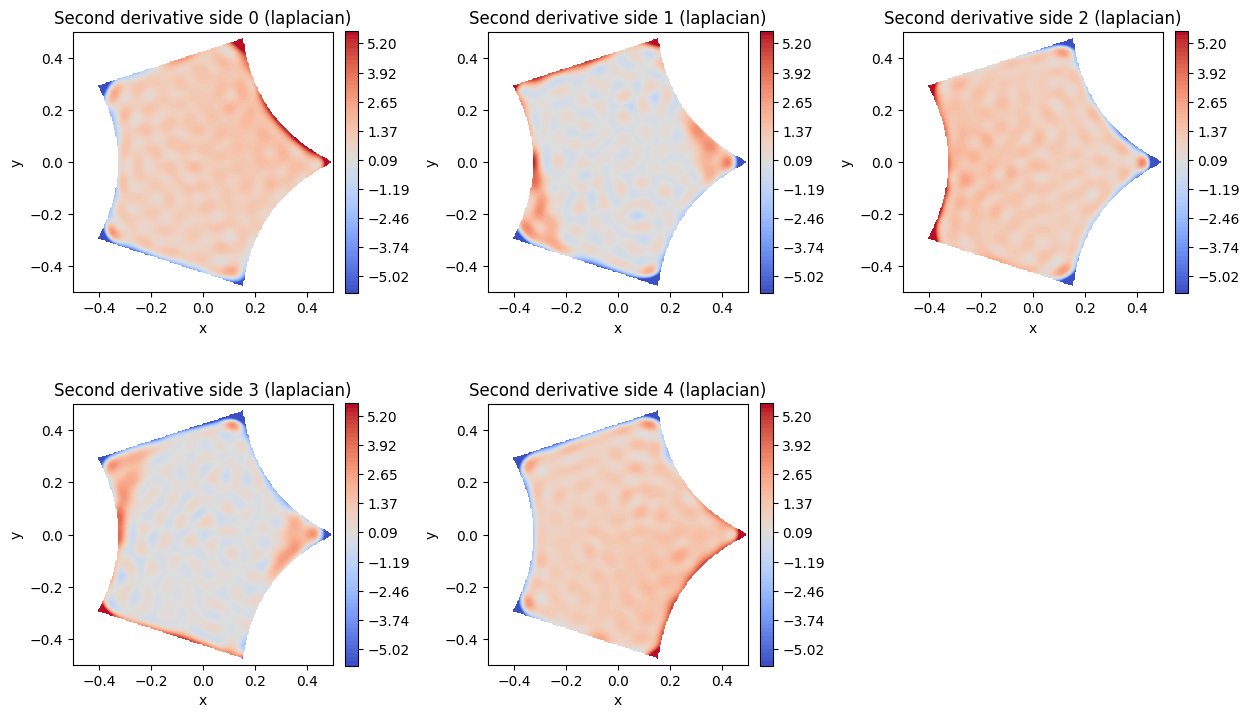

(<Figure size 1260x760 with 11 Axes>,
 array([[<Axes: title={'center': 'Second derivative side 0 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 1 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 2 (laplacian)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Second derivative side 3 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 4 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[  3.14775116,  -1.94357329,  -1.92929888,  -3.61082435,
            3.19548689],
         [  2.50664525,  -2.434226  ,  -1.42409336,  -2.22803031,
            2.7113337 ],
         [  1.85193227,  -2.7847577 ,  -0.84804239,  -0.8497868 ,
            2.14341253],
         ...,
         [ 18.67645796,  -4.16798057, -19.12592188, -10.3760645 ,
            7.96935681],
         [ 18.73182997,  -4.59694685, -18.19227558, 

In [33]:
NI.plot_local_per_side_second_derivative(model2, extent=[-0.5,0.5,-0.5,0.5], fun_num=FUN_NUM, device=torch.device('cpu'))